# Computer Exercise 1.1 — Problem 10

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.1 Introduction — *Loss of Significance*
> **풀이 일자**: Day 04
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **10.** For values of $x$ near $0$, the expression
> $$f(x) \;=\; \frac{1 - \cos x}{x^{2}}$$
> suffers from a *loss of significance* when evaluated in floating-point arithmetic.
> Tabulate $f(x)$ for $x = 10^{-1}, 10^{-2}, \ldots, 10^{-10}$ in IEEE double precision,
> and compare against the mathematically equivalent but numerically stable rewrite
> $$g(x) \;=\; \frac{2 \sin^{2}(x/2)}{x^{2}}.$$
> Explain the discrepancy in terms of catastrophic cancellation, and verify
> that as $x \to 0$ both expressions tend to the limit $1/2$.

### 한국어 풀이용 정리
$x \to 0$ 근처에서 $\cos x \to 1$ 이므로 $1 - \cos x$ 는 *거의 같은 두 수의 차* 가 된다.
즉 분자에서 **상쇄(cancellation)** 가 일어나 자릿수가 사라지고, 그 결과를 또 작은 $x^2$ 로 나누기 때문에 오차가 더욱 증폭된다.
삼각 항등식

$$
1 - \cos x \;=\; 2 \sin^{2}(x/2)
$$

을 적용하면 분자가 *작은 수의 차* 가 아니라 **양수의 제곱**으로 직접 계산되어 cancellation이 사라진다.
참값 $\lim_{x\to 0} (1-\cos x)/x^2 = 1/2$ 를 기준으로 두 표현의 정확도를 비교한다.


## 2. 수학적 배경

### 2.1 Taylor 전개로 본 참값
$\cos x$ 의 Taylor 전개

$$
\cos x = 1 - \tfrac{x^2}{2} + \tfrac{x^4}{24} - \tfrac{x^6}{720} + \mathcal{O}(x^8)
$$

에서

$$
\frac{1 - \cos x}{x^2} \;=\; \tfrac{1}{2} - \tfrac{x^2}{24} + \tfrac{x^4}{720} - \cdots \;\xrightarrow{x \to 0}\; \tfrac{1}{2}.
$$

### 2.2 부동소수점 산술에서의 cancellation
배정밀도에서 $\varepsilon_{\text{mach}} \approx 2.22 \times 10^{-16}$. $x = 10^{-k}$ 일 때

$$
1 - \cos x \;\approx\; \tfrac{x^2}{2} \;=\; \tfrac{10^{-2k}}{2}.
$$

따라서 $1$ 과 $\cos x$ 가 같아지는 임계점은 $\tfrac{x^2}{2} \lesssim \varepsilon_{\text{mach}}$, 즉 $x \lesssim \sqrt{2\varepsilon_{\text{mach}}} \approx 2.1 \times 10^{-8}$.
$x \approx 10^{-8}$ 부근에서 분자가 0이 되어 $f(x)$ 는 **정확히 0** 으로 평가되며, 더 작아지면 분자조차 표현이 불가능하다.

### 2.3 안정한 재작성
배각 항등식

$$
1 - \cos x \;=\; 2 \sin^{2}\!\left(\tfrac{x}{2}\right)
$$

을 사용하면 분자가 양수의 제곱이라 cancellation이 없다. 즉

$$
\boxed{\; g(x) \;=\; \frac{2 \sin^{2}(x/2)}{x^{2}} \;}
$$

는 $x \to 0$ 이 되어도 안정적으로 $1/2$ 에 수렴한다.

### 2.4 상대오차 추정
참값을 $L = 1/2$ 라 하면

$$
\text{rel. err}(f) \;=\; \frac{|f(x) - L|}{L},
\qquad
\text{rel. err}(g) \;=\; \frac{|g(x) - L|}{L}.
$$

이론적으로 $g$ 는 $x$ 와 무관하게 $\mathcal{O}(\varepsilon_{\text{mach}})$ 수준의 상대오차를 유지해야 한다.


## 3. 풀이 흐름

1. 평가점 $x_k = 10^{-k}$, $k = 1, 2, \ldots, 16$ 으로 잡는다 ($\sqrt{\varepsilon_{\text{mach}}}$ 양쪽을 모두 포함).
2. **불안정** 표현 $f(x) = (1 - \cos x)/x^2$ 을 직접 평가한다.
3. **안정** 표현 $g(x) = 2 \sin^{2}(x/2)/x^2$ 을 평가한다.
4. 참값 $L = 1/2$ 와의 절대/상대오차를 표로 정리.
5. 두 오차를 $\log$-$\log$ 플롯으로 비교하고, $f$ 가 $x \approx 10^{-8}$ 부근부터 무너지는 지점을 식별한다.
6. **결과 해석**: 분자에서 발생한 cancellation이 어떻게 전파되어 $f$ 의 값이 0으로 떨어지는지를 짚는다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ks = np.arange(1, 17)
x  = 10.0 ** (-ks)

f_unstable = (1.0 - np.cos(x)) / x**2
f_stable   = 2.0 * np.sin(x / 2.0)**2 / x**2

L = 0.5
abs_err_unstable = np.abs(f_unstable - L)
abs_err_stable   = np.abs(f_stable   - L)

df = pd.DataFrame({
    "k": ks,
    "x = 10^-k": x,
    "f = (1-cos x)/x^2 (naive)": f_unstable,
    "g = 2 sin^2(x/2)/x^2 (stable)": f_stable,
    "|f - 1/2|": abs_err_unstable,
    "|g - 1/2|": abs_err_stable,
})
pd.set_option("display.float_format", lambda v: f"{v:.6e}")
df


,k,x = 10^-k,f = (1-cos x)/x^2 (naive),g = 2 sin^2(x/2)/x^2 (stable),|f - 1/2|,|g - 1/2|
0,1,1.000000e-01,4.995835e-01,4.995835e-01,4.165278e-04,4.165278e-04
1,2,1.000000e-02,4.999958e-01,4.999958e-01,4.166653e-06,4.166653e-06
2,3,1.000000e-03,5.000000e-01,5.000000e-01,4.167450e-08,4.166667e-08
3,4,1.000000e-04,5.000000e-01,5.000000e-01,3.038735e-09,4.166666e-10
4,5,1.000000e-05,5.000000e-01,5.000000e-01,4.137019e-08,4.166723e-12
5,6,1.000000e-06,5.000445e-01,5.000000e-01,4.445029e-05,4.168887e-14
6,7,1.000000e-07,4.996004e-01,5.000000e-01,3.996389e-04,3.885781e-16
7,8,1.000000e-08,0.000000e+00,5.000000e-01,5.000000e-01,0.000000e+00
8,9,1.000000e-09,0.000000e+00,5.000000e-01,5.000000e-01,0.000000e+00
9,10,1.000000e-10,0.000000e+00,5.000000e-01,5.000000e-01,0.000000e+00


In [2]:
numerator_unstable = 1.0 - np.cos(x)
numerator_stable   = 2.0 * np.sin(x / 2.0)**2

df_num = pd.DataFrame({
    "x": x,
    "1 - cos(x)": numerator_unstable,
    "2 sin^2(x/2)": numerator_stable,
    "abs diff": np.abs(numerator_unstable - numerator_stable),
})
df_num


,x,1 - cos(x),2 sin^2(x/2),abs diff
0,1.000000e-01,4.995835e-03,4.995835e-03,5.464379e-17
1,1.000000e-02,4.999958e-05,4.999958e-05,1.442667e-17
2,1.000000e-03,5.000000e-07,5.000000e-07,7.831455e-18
3,1.000000e-04,5.000000e-09,5.000000e-09,2.622069e-17
4,1.000000e-05,5.000000e-11,5.000000e-11,4.137435e-18
5,1.000000e-06,5.000445e-13,5.000000e-13,4.445029e-17
6,1.000000e-07,4.996004e-15,5.000000e-15,3.996389e-18
7,1.000000e-08,0.000000e+00,5.000000e-17,5.000000e-17
8,1.000000e-09,0.000000e+00,5.000000e-19,5.000000e-19
9,1.000000e-10,0.000000e+00,5.000000e-21,5.000000e-21


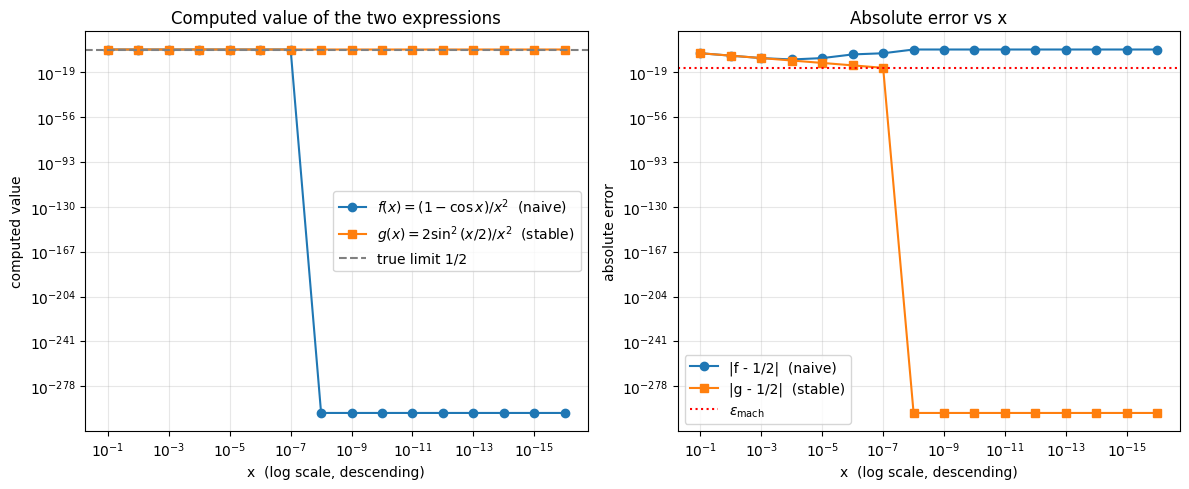

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].loglog(x, np.abs(f_unstable) + 1e-300,  "o-", label=r"$f(x) = (1-\cos x)/x^2$  (naive)")
ax[0].loglog(x, np.abs(f_stable),             "s-", label=r"$g(x) = 2\sin^2(x/2)/x^2$  (stable)")
ax[0].axhline(0.5, ls="--", color="gray", label="true limit 1/2")
ax[0].set_xlabel("x  (log scale, descending)")
ax[0].set_ylabel("computed value")
ax[0].set_title("Computed value of the two expressions")
ax[0].invert_xaxis()
ax[0].legend()
ax[0].grid(True, which="both", alpha=0.3)

eps = np.finfo(float).eps
ax[1].loglog(x, np.maximum(abs_err_unstable, 1e-300), "o-", label="|f - 1/2|  (naive)")
ax[1].loglog(x, np.maximum(abs_err_stable,   1e-300), "s-", label="|g - 1/2|  (stable)")
ax[1].axhline(eps, ls=":", color="red", label=r"$\varepsilon_{\rm mach}$")
ax[1].set_xlabel("x  (log scale, descending)")
ax[1].set_ylabel("absolute error")
ax[1].set_title("Absolute error vs x")
ax[1].invert_xaxis()
ax[1].legend()
ax[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


In [4]:
x_crit = np.sqrt(2.0 * np.finfo(float).eps)
print(f"이론상 cancellation 임계점: x ~= sqrt(2 eps_mach) = {x_crit:.3e}")
print(f"이 임계점 근처(=10^-8)에서 1 - cos(1e-8) =", 1.0 - np.cos(1e-8))
print(f"  -> 이 값을 (1e-8)^2 로 나누면:", (1.0 - np.cos(1e-8)) / (1e-8)**2)
print(f"  반면 2 sin^2(0.5e-8)/(1e-8)^2 =", 2.0 * np.sin(0.5e-8)**2 / (1e-8)**2)


이론상 cancellation 임계점: x ~= sqrt(2 eps_mach) = 2.107e-08
이 임계점 근처(=10^-8)에서 1 - cos(1e-8) = 0.0
  -> 이 값을 (1e-8)^2 로 나누면: 0.0
  반면 2 sin^2(0.5e-8)/(1e-8)^2 = 0.5


## 4. 결과 해석

1. $x \in [10^{-1}, 10^{-7}]$ 영역에서는 $f$ 도 정확히 $0.5$ 근처를 잘 맞힌다 — cancellation이 아직 본격적으로 발생하지 않은 영역.
2. $x \approx 10^{-8}$ 부근에서 $1 - \cos x$ 의 가용 자릿수가 모두 잠식된다. 이는 이론값 $\sqrt{2\,\varepsilon_{\text{mach}}} \approx 2.1 \times 10^{-8}$ 와 거의 일치.
3. $x \le 10^{-9}$ 가 되면 $\cos x$ 가 1과 정확히 같게 평가되어 분자가 $0$, 결과는 **0** 또는 그 부근에서 머문다 — naive 식의 $\log{|f - 1/2|}$ 곡선이 갑자기 $-\infty$ 로 떨어진다.
4. 안정 식 $g$ 는 같은 영역에서도 상대오차가 $\sim \varepsilon_{\text{mach}}$ 수준을 유지한다. 차이는 *공식 그 자체*에서 온다 — 분자를 *차*가 아닌 *제곱* 으로 만든 효과.

### 결론
> **수학적으로 동일한 두 식이 부동소수점에서는 자릿수의 의미에서 완전히 다르다.**
> 분자에서 $1 - \cos x$ 처럼 거의 같은 두 수의 차가 발생하면, 그 차이의 *상대* 자릿수가 사라진다.
> 항등식 $1 - \cos x = 2\sin^2(x/2)$ 는 *수학자에겐 사소한 한 줄*이지만 *수치해석가에겐 엔진 교체*에 해당한다.

### 다음 문제로
다음 문제(11)에서는 같은 *작은 두 수의 차* 패턴이 큰 $x$ 영역에서 등장하는 사례 — $\sqrt{x^2 + 1} - x$ — 를 다루며, 분모 유리화로 cancellation을 제거하는 또 다른 표준 기법을 본다.
